# **<center> MileStone 2: Data Cleaning & EDA Notebook</center>**

**Objective:** Explore crop production, yield, and acreage trends across U.S. states. This notebook focuses on identifying geographic productivity clusters, evaluating temporal growth trends, and analyzing the relationship between land usage and total output.

**Dataset Source:** Crop data accessed through through USDA NASS Quick Stats database(https://quickstats.nass.usda.gov/). Corn dataset accessed through Kaggle (https://www.kaggle.com/datasets/meongsuzacklee/us-corn-data) sourced through USDA NASS Quick Stats database(https://quickstats.nass.usda.gov/). Weather data accessed through National Centers for Environmental Information (https://www.ncei.noaa.gov/access/monitoring/climate-at-a-glance/statewide/time-series/service-api). 

**Reproducibility rule:** `Kernel → Restart & Run All` should work without errors.

**Workflow:** 

1. Crops Across United States:  Imports → Data creation → Data Cleaning and Checks → EDA Visuals)
2. Analyzing Corn Data: Imports → Data creation → Data Cleaning and Checks → EDA Visuals) 
3. Weather Patterns: Imports → Data creation → Data Cleaning and Checks → EDA Visuals) 
4. Initial Findings 
5. Hypothesis for further exploration.


**Made by:** Annan Zia

### **Imports**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## **CROPS ACROSS United States**

Limiting scope to one crop 

### **Data Loading**

In [2]:
crops_df = pd.read_csv("data/us_state_crop_yield.csv")

### **Inspecting Data**

In [3]:
# Loading the first 5 rows to inspect the data
crops_df.head()

,YEAR,CROP,STATE,YIELD,UNIT
0,2000,BARLEY,ALASKA,31.1,BU / ACRE
1,2000,BARLEY,ARIZONA,114,BU / ACRE
2,2000,BARLEY,CALIFORNIA,68,BU / ACRE
3,2000,BARLEY,COLORADO,115,BU / ACRE
4,2000,BARLEY,DELAWARE,81,BU / ACRE


In [4]:
# Loading 5 random rows to inspect the data
crops_df.sample(5)

,YEAR,CROP,STATE,YIELD,UNIT
3788,2014,PEANUTS,GEORGIA,"4,135",LB / ACRE
1336,2005,BARLEY,VIRGINIA,87,BU / ACRE
3661,2014,BARLEY,KANSAS,35,BU / ACRE
5792,2022,HAY & HAYLAGE,MINNESOTA,2.76,TONS / ACRE
4359,2016,SOYBEANS,KANSAS,48,BU / ACRE


In [5]:
# Loading the last 5 rows to inspect the data
crops_df.tail()

,YEAR,CROP,STATE,YIELD,UNIT
5920,2022,WHEAT,UTAH,36,BU / ACRE
5921,2022,WHEAT,VIRGINIA,68,BU / ACRE
5922,2022,WHEAT,WASHINGTON,63.4,BU / ACRE
5923,2022,WHEAT,WISCONSIN,78,BU / ACRE
5924,2022,WHEAT,WYOMING,17,BU / ACRE


In [6]:
crops_df.dtypes

YEAR      int64
CROP     object
STATE    object
YIELD    object
UNIT     object
dtype: object

In [7]:
# Checking Shape of data
crops_df.shape

(5925, 5)

### **Cleaning Data**

In [8]:
crops_df['YIELD'] = pd.to_numeric(crops_df['YIELD'].astype(str).str.replace(',', ''), errors='coerce')

In [9]:
crops_df.dtypes

YEAR       int64
CROP      object
STATE     object
YIELD    float64
UNIT      object
dtype: object

### **Feature Engineering**

Data has different units so we will switch to one Unit which is LB / ACRE

In [10]:
def convert_to_lbs(row):
    unit = row['UNIT']
    value = row['YIELD']
    crop = row['CROP']
    
    if unit == 'TONS / ACRE':
        return value * 2000
    elif unit == 'LB / ACRE':
        return value
    elif unit == 'BU / ACRE':
        # Apply grain-specific weights
        weights = {
            'CORN': 56, 'SOYBEANS': 60, 'WHEAT': 60, 'OATS': 32,
            'BARLEY': 48, 'SORGHUM': 56, 'RYE': 56, 'FLAXSEED': 56
        }
        return value * weights.get(crop, 1) # Default to 1 if crop not in list
    return value

crops_df['YIELD_LB_PER_ACRE'] = crops_df.apply(convert_to_lbs, axis=1)

In [11]:
crops_df.head()

,YEAR,CROP,STATE,YIELD,UNIT,YIELD_LB_PER_ACRE
0,2000,BARLEY,ALASKA,31.1,BU / ACRE,1492.8
1,2000,BARLEY,ARIZONA,114.0,BU / ACRE,5472.0
2,2000,BARLEY,CALIFORNIA,68.0,BU / ACRE,3264.0
3,2000,BARLEY,COLORADO,115.0,BU / ACRE,5520.0
4,2000,BARLEY,DELAWARE,81.0,BU / ACRE,3888.0


### **Describing Data**

In [12]:
descriptions = [
    "The specific harvest year the agricultural data was recorded.",
    "The type of agricultural commodity grown and harvested (e.g., Corn, Wheat, Soybeans).",
    "The U.S. state where the crop production took place.",
    "The raw production volume per acre, measured in its original reporting unit.",
    "The original unit of measurement for the reported yield (e.g., BU / ACRE, TONS / ACRE).",
    "The standardized crop yield converted into pounds per acre to allow for consistent, mathematical comparisons across different crops."
]


print("Description of Column Names")
print("---------------------------")
for x in range(len(descriptions)):
    print (crops_df.columns[x], ":", descriptions[x])

Description of Column Names
---------------------------
YEAR : The specific harvest year the agricultural data was recorded.
CROP : The type of agricultural commodity grown and harvested (e.g., Corn, Wheat, Soybeans).
STATE : The U.S. state where the crop production took place.
YIELD : The raw production volume per acre, measured in its original reporting unit.
UNIT : The original unit of measurement for the reported yield (e.g., BU / ACRE, TONS / ACRE).
YIELD_LB_PER_ACRE : The standardized crop yield converted into pounds per acre to allow for consistent, mathematical comparisons across different crops.


In [13]:
crops_df.describe()

,YEAR,YIELD,YIELD_LB_PER_ACRE
count,5925.000000,5906.000000,5906.000000
mean,2010.837637,619.398666,7193.501998
std,6.580435,1350.309370,14195.732247
min,2000.000000,0.000000,0.000000
25%,2005.000000,40.000000,2040.000000
50%,2011.000000,72.000000,3240.000000
75%,2016.000000,220.000000,6160.000000
max,2022.000000,11300.000000,98400.000000


In [14]:
print(f"There are {len(crops_df[crops_df['YIELD'] == 0])} entries with 0 Yield.")

There are 61 entries with 0 Yield.


Some crops have YIELD of 0 which could be a cause of missing data. I investigated this and it turns out to be the true 0 so I chose keep this in the dataframe.

### **Anomaly Detection**

In [15]:
# IQR Method for Yield Outliers
Q1 = crops_df['YIELD_LB_PER_ACRE'].quantile(0.25)
Q3 = crops_df['YIELD_LB_PER_ACRE'].quantile(0.75)

IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = crops_df[(crops_df['YIELD'] < lower) | (crops_df['YIELD'] > upper)]

print(f"There are {len(outliers)} outliers out of {len(crops_df)} records.")

There are 0 outliers out of 5925 records.


### **EDA Visuals**

1. Geographic Distribution of Crop Cultivation (Horizontal Bar Chart)

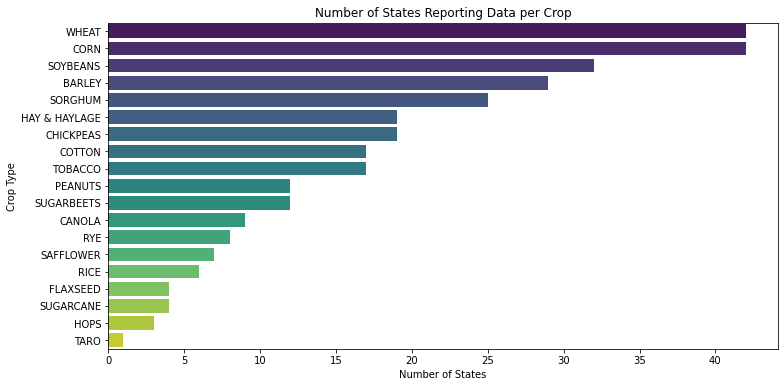

In [16]:
state_counts = crops_df.groupby('CROP')['STATE'].nunique().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=state_counts, x='STATE', y='CROP', palette='viridis')

plt.title('Number of States Reporting Data per Crop')
plt.xlabel('Number of States')
plt.ylabel('Crop Type')

plt.show()

    Caption: The horizontal bar chart shows the geographic footprint of various crops across the United States by tracking the number of reporting states. Notably, Corn and Wheat emerge as the most widely cultivated commodities, with data available from nearly every state in the country. Both of them are cultivated in 50 states. This widespread national representation makes both crops excellent candidates for a robust, macro-level analysis. Majority of other crops experience a sharp drop-off, restricting our ability to perform nationwide comparative analysis on them.

2. Average Yield by Crop (bar chart)

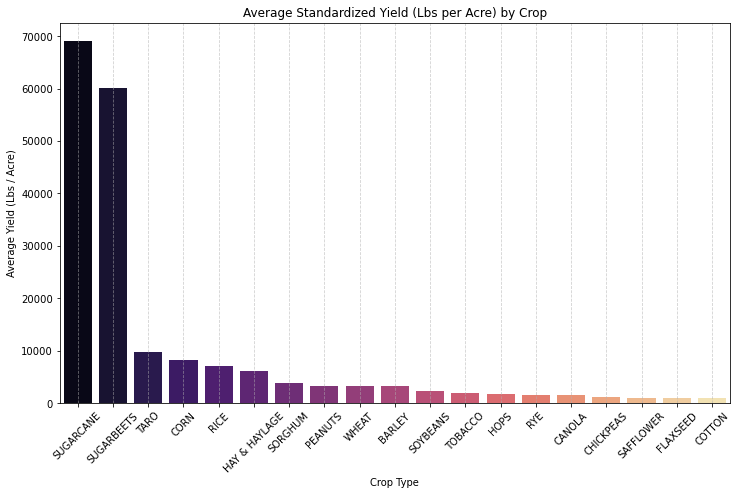

In [17]:
avg_yield_lbs = crops_df.groupby('CROP')['YIELD_LB_PER_ACRE'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 7))
sns.barplot(data=avg_yield_lbs, y='YIELD_LB_PER_ACRE', x='CROP', palette='magma')

plt.title('Average Standardized Yield (Lbs per Acre) by Crop')
plt.ylabel('Average Yield (Lbs / Acre)')
plt.xlabel('Crop Type')
plt.xticks(rotation=45)
plt.grid(axis='x', linestyle='--', alpha=0.6)

    Caption: This bar chart shows the yield in lbs per acres across each crop grown in the US. While sugarcane and sugarbeets report the highest average yields per acre, their restricted geographic footprint makes them weak candidates for a representative national study. Comparing our previously identified widespread candidates, corn demonstrates a much higher average yield than wheat, while other crops like soybeans and oats show even lower biomass efficiency. Thus this strengthens corn's position as the optimal focus for analyzing broad weather-driven productivity trends.

3. Comparison of Raw Yield Distributions Across Measurement Units (Box and whisker plots)

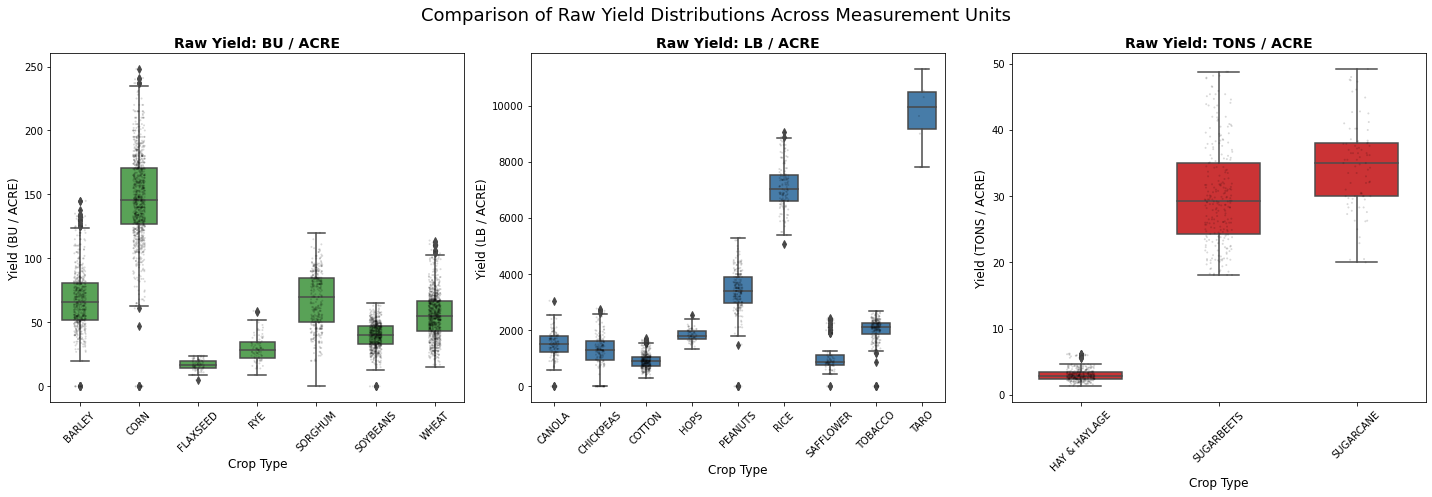

In [18]:
units = ['BU / ACRE', 'LB / ACRE', 'TONS / ACRE']
colors = ['#4DAF4A', '#377EB8', '#E41A1C']
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# Iterate through units to populate each subplot
for i, unit in enumerate(units):
    subset = crops_df[crops_df['UNIT'] == unit]
    
    if not subset.empty:
        # Create boxplot for range and stripplot for individual data points
        sns.boxplot(ax=axes[i], data=subset, x='CROP', y='YIELD', color=colors[i], width=0.6)
        sns.stripplot(ax=axes[i], data=subset, x='CROP', y='YIELD', color='black', alpha=0.15, size=2)
        
        axes[i].set_title(f'Raw Yield: {unit}', fontsize=14, fontweight='bold')
        axes[i].set_xlabel('Crop Type', fontsize=12)
        axes[i].set_ylabel(f'Yield ({unit})', fontsize=12)
        axes[i].tick_params(axis='x', rotation=45)
plt.suptitle('Comparison of Raw Yield Distributions Across Measurement Units', fontsize=18)
plt.tight_layout()
plt.show()

    Caption: This visualisation shows a box and whisker plot for each type of individual units plotted with a subplot. The "Tons" plot shows that sugarcane and sugarbeets achieve the highest average yields per acre, but their limited regional presence makes them weak candidates for national analysis. Among the more widespread candidates, the "Bushels" plot reveals that corn produces significantly higher average yields than wheat, while other crops across all units consistently show lower productivity, pointing toward corn as the most robust choice for a comprehensive study.

From our visualizations and analysis above, our strongest competitor for analyzing is Corn as it uniquely combines a near-universal geographic presence with superior biological efficiency. While specialized crops like sugarcane and sugarbeets show higher raw tonnage in specific regions, their limited national footprint makes them weak candidates for a broad study. Conversely, corn consistently outperforms other widespread staples like wheat in both standardized and raw output across almost all states, providing the most robust and representative dataset for investigating yield trends.

# Using Corn data

### **Data Loading**

In [19]:
corn_df = pd.read_csv("data/us_state_corn.csv")

### **Inspecting Data**

In [20]:
# Loading the first 5 rows to inspect the data
corn_df.head()

,YEAR,STATE,STATE ANSI,CORN_PRICE RECEIVED_$ / BU,CORN_ACRES PLANTED_ACRE,CORN_ACRES HARVESTED_ACRE,CORN_PRODUCTION_BU
0,2022,ALABAMA,1,7.15,300000.0,290000.0,34220000.0
1,2022,ARIZONA,4,8.70,80000.0,40000.0,8800000.0
2,2022,ARKANSAS,5,6.65,710000.0,695000.0,120235000.0
3,2022,CALIFORNIA,6,8.00,370000.0,20000.0,3540000.0
4,2022,COLORADO,8,7.50,1350000.0,980000.0,118580000.0


In [21]:
# Loading 5 random rows to inspect the data
corn_df.sample(5)

,YEAR,STATE,STATE ANSI,CORN_PRICE RECEIVED_$ / BU,CORN_ACRES PLANTED_ACRE,CORN_ACRES HARVESTED_ACRE,CORN_PRODUCTION_BU
727,2005,PENNSYLVANIA,42,2.30,1350000.0,960000.0,117120000.0
69,2021,OKLAHOMA,40,6.14,340000.0,295000.0,44250000.0
436,2012,NORTH DAKOTA,38,6.46,3640000.0,3460000.0,422120000.0
247,2016,ARIZONA,4,4.73,95000.0,50000.0,10750000.0
492,2010,ALABAMA,1,5.07,270000.0,250000.0,28750000.0


In [22]:
# Loading the last 5 rows to inspect the data
corn_df.tail()

,YEAR,STATE,STATE ANSI,CORN_PRICE RECEIVED_$ / BU,CORN_ACRES PLANTED_ACRE,CORN_ACRES HARVESTED_ACRE,CORN_PRODUCTION_BU
938,2000,VIRGINIA,51,2.02,470000.0,330000.0,48180000.0
939,2000,WASHINGTON,53,2.53,155000.0,100000.0,18500000.0
940,2000,WEST VIRGINIA,54,2.08,55000.0,35000.0,4550000.0
941,2000,WISCONSIN,55,1.86,3500000.0,2750000.0,363000000.0
942,2000,WYOMING,56,2.02,90000.0,58000.0,7656000.0


In [23]:
# Checking data Types
corn_df.dtypes

YEAR                            int64
STATE                          object
STATE ANSI                      int64
CORN_PRICE RECEIVED_$ / BU    float64
CORN_ACRES PLANTED_ACRE       float64
CORN_ACRES HARVESTED_ACRE     float64
CORN_PRODUCTION_BU            float64
dtype: object

In [24]:
# Checking Shape of data
corn_df.shape

(943, 7)

In [25]:
# Checking for nonnull values
corn_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 943 entries, 0 to 942
Data columns (total 7 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   YEAR                        943 non-null    int64  
 1   STATE                       943 non-null    object 
 2   STATE ANSI                  943 non-null    int64  
 3   CORN_PRICE RECEIVED_$ / BU  943 non-null    float64
 4   CORN_ACRES PLANTED_ACRE     943 non-null    float64
 5   CORN_ACRES HARVESTED_ACRE   943 non-null    float64
 6   CORN_PRODUCTION_BU          943 non-null    float64
dtypes: float64(4), int64(2), object(1)
memory usage: 51.7+ KB


### **Cleaning Data**

In [26]:
# Removing space from the column names with _
corn_df.columns = [c.strip().replace(' ', '_') for c in corn_df.columns]

# Changing the name of one of the columns
corn_df.rename(columns={'CORN_PRICE_RECEIVED_$_/_BU': 'CORN_PRICE_USD_PER_BU'}, inplace=True)

In [27]:
# Checking for duplicates and removing them so results are not skewed
corn_df = corn_df.drop_duplicates()

In [28]:
# Checking for null values
corn_df.isnull().sum()

YEAR                         0
STATE                        0
STATE_ANSI                   0
CORN_PRICE_USD_PER_BU        0
CORN_ACRES_PLANTED_ACRE      0
CORN_ACRES_HARVESTED_ACRE    0
CORN_PRODUCTION_BU           0
dtype: int64

In [29]:
# Handling Nulls
# We drop rows where Production or Harvested Acres are missing 
# because we cannot calculate the yield with them missing.
corn_df = corn_df.dropna(subset=['CORN_PRODUCTION_BU', 'CORN_ACRES_HARVESTED_ACRE'])

### **Describing Data**

In [30]:
descriptions = [
    "The specific calendar year in which the agricultural data was recorded and reported.", 
    "The name of the U.S. state where the corn production and pricing activity took place.",
    "The Federal Information Processing Standard (FIPS) numeric code used for standardized geographic identification of states", 
    "The average market price, measured in U.S. Dollars, that farmers received for one bushel of corn.",
    "The total land area, measured in acres, where corn seeds were originally sown during the planting season.",
    "The actual land area, measured in acres, from which corn was successfully removed and collected for production.",
    "The total volume of corn produced across the specified state and year, measured in bushels."
]


print("Description of Column Names")
print("---------------------------")
for x in range(7):
    print (corn_df.columns[x], ":", descriptions[x])

Description of Column Names
---------------------------
YEAR : The specific calendar year in which the agricultural data was recorded and reported.
STATE : The name of the U.S. state where the corn production and pricing activity took place.
STATE_ANSI : The Federal Information Processing Standard (FIPS) numeric code used for standardized geographic identification of states
CORN_PRICE_USD_PER_BU : The average market price, measured in U.S. Dollars, that farmers received for one bushel of corn.
CORN_ACRES_PLANTED_ACRE : The total land area, measured in acres, where corn seeds were originally sown during the planting season.
CORN_ACRES_HARVESTED_ACRE : The actual land area, measured in acres, from which corn was successfully removed and collected for production.
CORN_PRODUCTION_BU : The total volume of corn produced across the specified state and year, measured in bushels.


In [31]:
# using .describe() for checking
corn_df.describe()

,YEAR,STATE_ANSI,CORN_PRICE_USD_PER_BU,CORN_ACRES_PLANTED_ACRE,CORN_ACRES_HARVESTED_ACRE,CORN_PRODUCTION_BU
count,943.000000,943.000000,943.000000,9.430000e+02,9.430000e+02,9.430000e+02
mean,2011.000000,30.073171,4.114730,2.123053e+06,1.938950e+06,3.052449e+08
std,6.636769,15.699539,1.522227,3.189087e+06,3.091567e+06,5.328057e+08
min,2000.000000,1.000000,1.530000,4.300000e+04,1.200000e+04,1.820000e+06
25%,2005.000000,18.000000,2.880000,1.750000e+05,8.550000e+04,1.608750e+07
50%,2011.000000,30.000000,3.930000,5.600000e+05,4.900000e+05,7.049000e+07
75%,2017.000000,42.000000,4.910000,2.800000e+06,2.585000e+06,3.286750e+08
max,2022.000000,56.000000,8.700000,1.420000e+07,1.390000e+07,2.740500e+09


In [32]:
# Checking to see if all states are valid and if they have repeated values
corn_df['STATE'].value_counts()

ALABAMA           23
NEBRASKA          23
NEW MEXICO        23
NEW YORK          23
NORTH CAROLINA    23
NORTH DAKOTA      23
OHIO              23
OKLAHOMA          23
OREGON            23
PENNSYLVANIA      23
SOUTH CAROLINA    23
SOUTH DAKOTA      23
TENNESSEE         23
TEXAS             23
UTAH              23
VIRGINIA          23
WASHINGTON        23
WEST VIRGINIA     23
WISCONSIN         23
NEW JERSEY        23
MONTANA           23
ARIZONA           23
MISSOURI          23
ARKANSAS          23
CALIFORNIA        23
COLORADO          23
DELAWARE          23
FLORIDA           23
GEORGIA           23
IDAHO             23
ILLINOIS          23
INDIANA           23
IOWA              23
KANSAS            23
KENTUCKY          23
LOUISIANA         23
MARYLAND          23
MICHIGAN          23
MINNESOTA         23
MISSISSIPPI       23
WYOMING           23
Name: STATE, dtype: int64

### **Feature Engineering**

In [33]:
# Adding new fields for doing analysis

# Yield per Acre: dividing overall corn production by area harvested to get yield per area
corn_df['CORN_YIELD_BU_PER_ACRE'] = corn_df['CORN_PRODUCTION_BU'] / corn_df['CORN_ACRES_HARVESTED_ACRE']

# Harvest Rate: dividing the total area where corn is harvested by the total it is planted to get the rate of harvestation
corn_df['CORN_HARVEST_RATE'] = corn_df['CORN_ACRES_HARVESTED_ACRE'] / corn_df['CORN_ACRES_PLANTED_ACRE']

# Revenue Estimate: Estimated revenue from total bushels of corn produced multiplied by its price per bushel
corn_df['ESTIMATED_REVENUE_USD'] = corn_df['CORN_PRICE_USD_PER_BU'] * corn_df['CORN_PRODUCTION_BU']

In [34]:
# Converting units into easier to read for visualisations 
corn_df['PRODUCTION_BILLIONS'] = corn_df['CORN_PRODUCTION_BU'] / 1e9
corn_df['ACRES_MILLIONS'] = corn_df['CORN_ACRES_HARVESTED_ACRE'] / 1e6

In [35]:
# Verifying Data Types
corn_df.dtypes

YEAR                           int64
STATE                         object
STATE_ANSI                     int64
CORN_PRICE_USD_PER_BU        float64
CORN_ACRES_PLANTED_ACRE      float64
CORN_ACRES_HARVESTED_ACRE    float64
CORN_PRODUCTION_BU           float64
CORN_YIELD_BU_PER_ACRE       float64
CORN_HARVEST_RATE            float64
ESTIMATED_REVENUE_USD        float64
PRODUCTION_BILLIONS          float64
ACRES_MILLIONS               float64
dtype: object

### **Anomaly Detection**

In [36]:
# IQR Method for Yield Outliers
Q1 = corn_df['CORN_YIELD_BU_PER_ACRE'].quantile(0.25)
Q3 = corn_df['CORN_YIELD_BU_PER_ACRE'].quantile(0.75)

IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = corn_df[(corn_df['CORN_YIELD_BU_PER_ACRE'] < lower) | (corn_df['CORN_YIELD_BU_PER_ACRE'] > upper)]

In [37]:
outliers

,YEAR,STATE,STATE_ANSI,CORN_PRICE_USD_PER_BU,CORN_ACRES_PLANTED_ACRE,CORN_ACRES_HARVESTED_ACRE,CORN_PRODUCTION_BU,CORN_YIELD_BU_PER_ACRE,CORN_HARVEST_RATE,ESTIMATED_REVENUE_USD,PRODUCTION_BILLIONS,ACRES_MILLIONS
29,2022,OREGON,41,8.40,75000.0,45000.0,10665000.0,237.0,0.600000,89586000.0,0.010665,0.045
70,2021,OREGON,41,7.23,95000.0,55000.0,13200000.0,240.0,0.578947,95436000.0,0.013200,0.055
78,2021,WASHINGTON,53,6.31,165000.0,85000.0,21080000.0,248.0,0.515152,133014800.0,0.021080,0.085
111,2020,OREGON,41,5.45,100000.0,65000.0,15665000.0,241.0,0.650000,85374250.0,0.015665,0.065
152,2019,OREGON,41,4.34,85000.0,49000.0,11613000.0,237.0,0.576471,50400420.0,0.011613,0.049
160,2019,WASHINGTON,53,4.13,175000.0,90000.0,21330000.0,237.0,0.514286,88092900.0,0.021330,0.090
842,2002,NEW JERSEY,34,2.77,90000.0,70000.0,4270000.0,61.0,0.777778,11827900.0,0.004270,0.070
851,2002,SOUTH CAROLINA,45,2.70,320000.0,260000.0,12220000.0,47.0,0.812500,32994000.0,0.012220,0.260


        These outliers show extreme values of both high and low yield which can have very important information so we should keep them included in out analysis.

### **EDA visualizations**

1. Yield Distribution (Histogram)

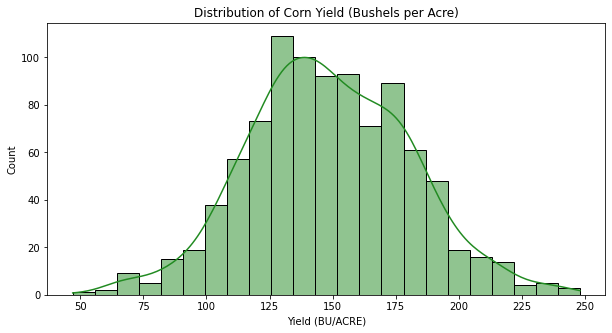

In [38]:
plt.figure(figsize=(10, 5))
sns.histplot(corn_df['CORN_YIELD_BU_PER_ACRE'], kde=True, color='forestgreen')
plt.title('Distribution of Corn Yield (Bushels per Acre)')
plt.xlabel('Yield (BU/ACRE)')
plt.show()

        The distribution of corn yield is concentrated within a moderate range of 140–160 bushels per acre, with a slight left skew indicating the presence of specific underperforming years. This suggests that while the majority of regions maintain a high productivity baseline, localized environmental stressors occasionally result in significant yield deficits that deviate from the national average.

2. Range and Outliers of Corn Prices (Box and Whisker Plot)

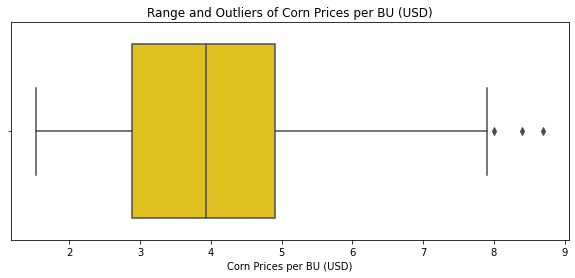

In [39]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=corn_df['CORN_PRICE_USD_PER_BU'], color='gold')
plt.title('Range and Outliers of Corn Prices per BU (USD)')
plt.xlabel('Corn Prices per BU (USD)')
plt.show()

        The price distribution for corn is clustered around a median of approximately $4.00, with several high-end outliers extending beyond $7.00 per bushel. This suggests that while market prices remain stable for long periods, specific years are subject to extreme market shocks likely driven by global inflationary pressures rather than domestic supply volume alone.

3. Corn Production vs. Harvested Acres (Scatter Plot)

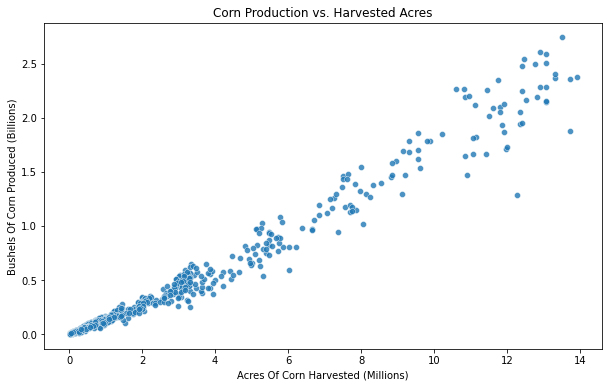

In [40]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=corn_df, x='ACRES_MILLIONS', y='PRODUCTION_BILLIONS', alpha=0.8)
plt.title('Corn Production vs. Harvested Acres')
plt.xlabel('Acres Of Corn Harvested (Millions)')
plt.ylabel('Bushels Of Corn Produced (Billions)')
plt.show()

        The average national corn yield exhibits a consistent upward temporal trend from 2000 to 2022, rising steadily from 130 to over 160 bushels per acre. This suggests that systematic advancements in agricultural technology and seed resilience are successfully driving long-term productivity growth across the domestic sector. 

4. U.S. Corn Yield Trend (Line Graph)

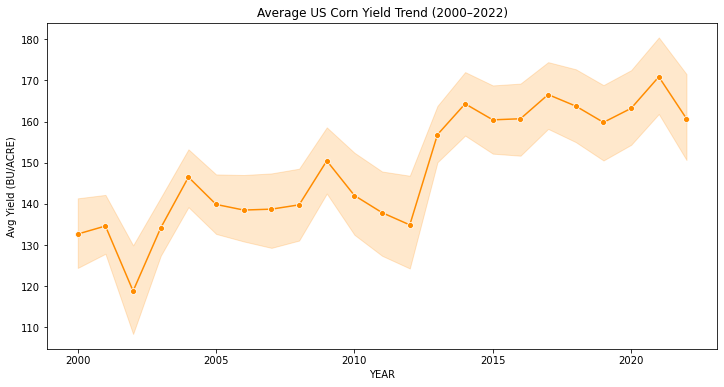

In [41]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=corn_df, x='YEAR', y='CORN_YIELD_BU_PER_ACRE', marker='o', color='darkorange')
plt.title('Average US Corn Yield Trend (2000–2022)')
plt.ylabel('Avg Yield (BU/ACRE)')
plt.show()

        The temporal trend for total national revenue exhibits significant volatility, with sharp economic peaks in the early 2010s and 2020s that far exceed historical averages. This suggests that the economic value of the corn market is highly sensitive to global pricing dynamics, making revenue much more volatile than physical yield.

5. Correlation Matrix of Agricultural Features (Correlation Heatmap)

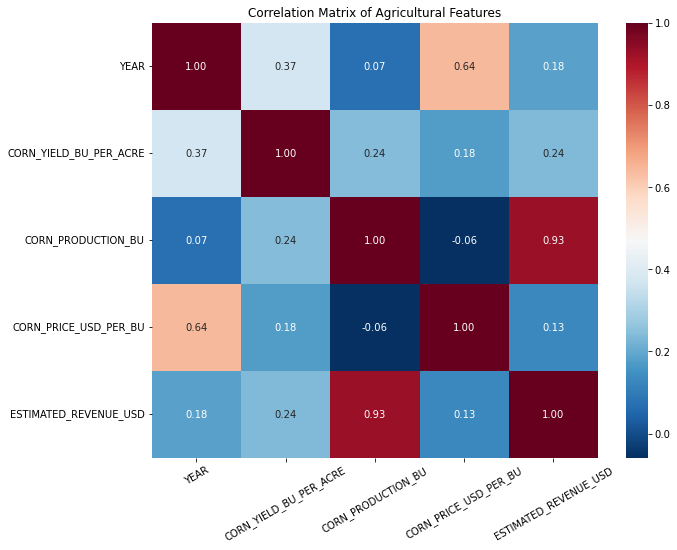

In [42]:
plt.figure(figsize=(10, 8))
corr = corn_df[['YEAR', 'CORN_YIELD_BU_PER_ACRE', 'CORN_PRODUCTION_BU', 'CORN_PRICE_USD_PER_BU', 'ESTIMATED_REVENUE_USD']].corr()
sns.heatmap(corr, annot=True, cmap='RdBu_r', fmt=".2f")
plt.title('Correlation Matrix of Agricultural Features')
plt.xticks(rotation=30)
plt.show()

        The correlation matrix reveals a near-perfect relationship between land use and output, while highlighting a moderate positive correlation between time and yield of 0.64. This suggests that while the physical scale of the harvest dictates supply volume, agricultural efficiency is improving as a predictable function of technological growth over time.

6. Top 10 States by Production (Bar Graph)

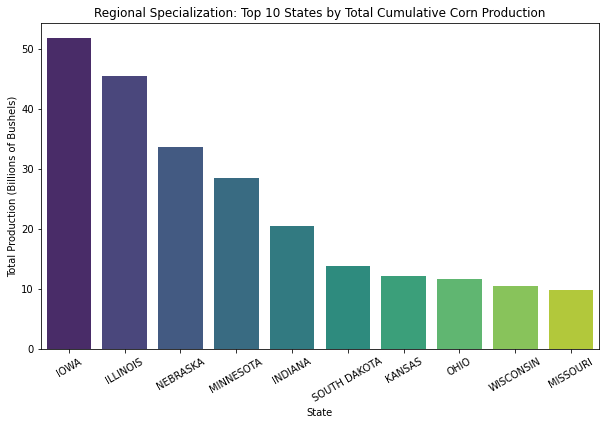

In [43]:
top_10_states = corn_df.groupby('STATE')['CORN_PRODUCTION_BU'].sum().nlargest(10).index
plot_data = corn_df[corn_df['STATE'].isin(top_10_states)].groupby('STATE')['CORN_PRODUCTION_BU'].sum().reset_index()
plot_data['PRODUCTION_BILLIONS'] = plot_data['CORN_PRODUCTION_BU'] / 1e9

plt.figure(figsize=(10, 6))
sns.barplot(data=plot_data, x='STATE', y='PRODUCTION_BILLIONS', order=top_10_states, palette='viridis')
plt.title('Regional Specialization: Top 10 States by Total Cumulative Corn Production')
plt.xlabel('State')
plt.ylabel('Total Production (Billions of Bushels)')
plt.xticks(rotation=30)
plt.show()

        Regional production is highly concentrated within a small number of "Corn Belt" states, with Iowa and Illinois serving as the primary drivers of total national volume. This suggests that the domestic agricultural supply chain is heavily dependent on a specific geographic corridor, making the national market highly sensitive to localized weather patterns within these top-tier states.

7. Yield Distribution Across Top 10 Producing States (Box and Whisker Plot)

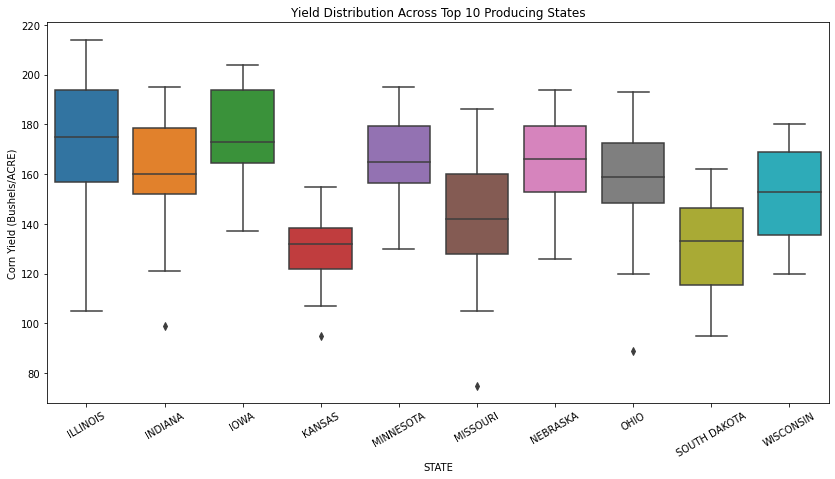

In [44]:
plt.figure(figsize=(14, 7))
sns.boxplot(data=corn_df[corn_df['STATE'].isin(top_10_states)], x='STATE', y='CORN_YIELD_BU_PER_ACRE')
plt.xticks(rotation=30)
plt.title('Yield Distribution Across Top 10 Producing States')
plt.ylabel('Corn Yield (Bushels/ACRE)')
plt.show()

        Variance in productivity differs significantly by region. Top-tier states like Iowa maintain a much higher "productivity floor" compared to peripheral states like South Dakota, which exhibit wider interquartile ranges. This suggests that certain geographic regions possess inherent climatic or infrastructural advantages that buffer them against the yield volatility seen in less specialized states

8. Yield Distribution over Years for Top 4 Producing Countries (Line graph)

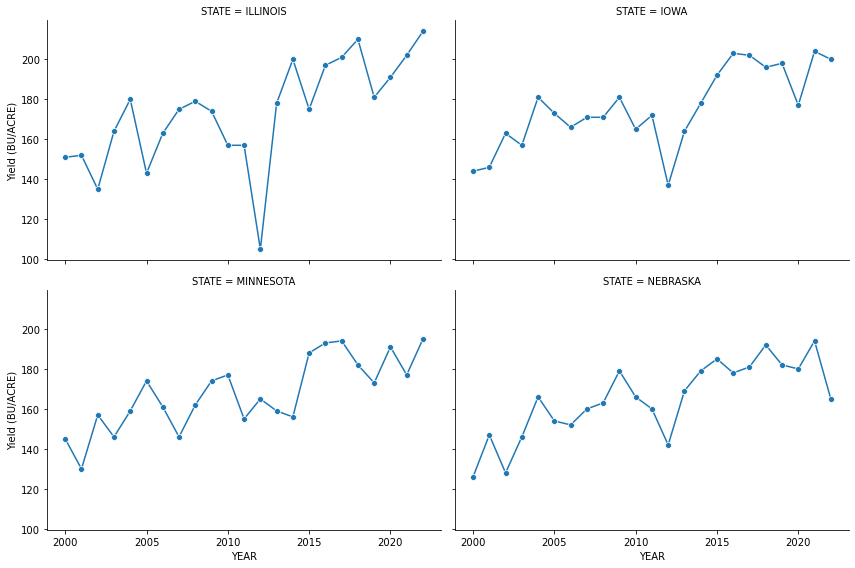

In [45]:
g = sns.FacetGrid(corn_df[corn_df['STATE'].isin(top_10_states[:4])], col="STATE", col_wrap=2, height=4, aspect=1.5)
g.map(sns.lineplot, "YEAR", "CORN_YIELD_BU_PER_ACRE", marker='o')
g.set_axis_labels("YEAR", "Yield (BU/ACRE)")
plt.show()

        Multi-state trajectories show synchronized yield fluctuations, particularly during widespread historical events like the 2012 drought. This suggests that large-scale environmental crises transcend state borders and impact the security of the entire domestic agricultural supply chain simultaneously.

9. Acreage vs Production (Scatter Plot)

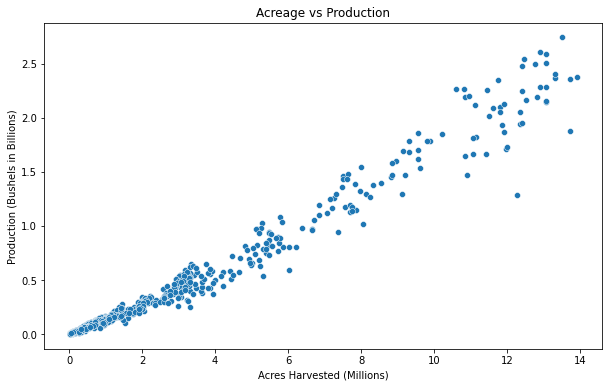

In [46]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=corn_df, x='ACRES_MILLIONS', y='PRODUCTION_BILLIONS')
plt.title('Acreage vs Production')
plt.xlabel('Acres Harvested (Millions)')
plt.ylabel('Production (Bushels in Billions)')
plt.show()

        The near-perfect positive relationship between harvested acreage and total production confirms that total output is primarily dictated by the physical scale of land usage. However, the presence of states achieving high production with relatively lower acreage suggests that land efficiency or yield is the key differentiator for regional agricultural competitiveness.

10. Revenue Analysis of Top 10 Producing States (Bar Graph)

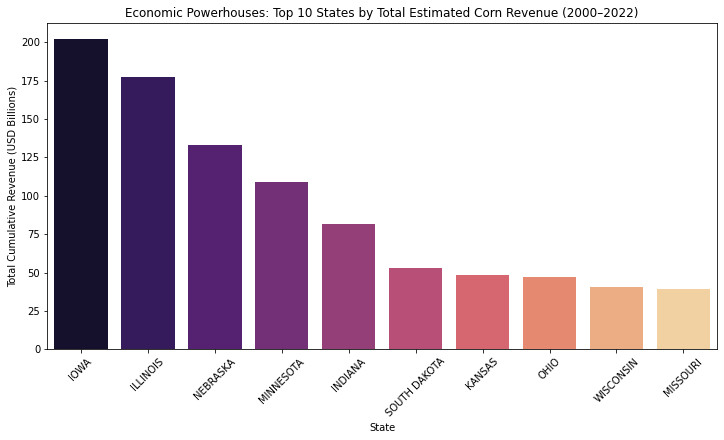

In [47]:
# Calculate total cumulative revenue per state
top_revenue_states = corn_df.groupby('STATE')['ESTIMATED_REVENUE_USD'].sum().nlargest(10).reset_index()
top_revenue_states['REVENUE_BILLIONS'] = top_revenue_states['ESTIMATED_REVENUE_USD'] / 1e9

plt.figure(figsize=(12, 6))
sns.barplot(data=top_revenue_states, x='STATE', y='REVENUE_BILLIONS', palette='magma')
plt.title('Economic Powerhouses: Top 10 States by Total Estimated Corn Revenue (2000–2022)')
plt.xlabel('State')
plt.ylabel('Total Cumulative Revenue (USD Billions)')
plt.xticks(rotation=45)
plt.show()

        Revenue patterns closely follow production levels, with the top-producing states also generating the greatest cumulative economic value. This reinforces the hypothesis that the economic health of the agricultural sector is inextricably linked to the environmental stability of these high-production regions.

## **Weather patterns and Corn Trends**

Now we will look at weather patterns and how it affects corn yield.

### **Loading Data**

In [48]:
weather_df = pd.read_csv("data/us_state_monthly_weather.csv")

### **Inspecting Data**

In [49]:
weather_df.head()

,YEAR,MONTH,STATE,PRECIPITATION,TEMP_AVG,TEMP_MAX,TEMP_MIN
0,2000,1,Alabama,4.69,46.5,57.1,35.9
1,2000,2,Alabama,1.99,52.3,66.2,38.4
2,2000,3,Alabama,5.05,58.9,72.1,45.6
3,2000,4,Alabama,4.83,60.1,73.4,46.8
4,2000,5,Alabama,1.32,74.0,86.3,61.6


In [50]:
weather_df.sample(5)

,YEAR,MONTH,STATE,PRECIPITATION,TEMP_AVG,TEMP_MAX,TEMP_MIN
8202,2016,7,Indiana,5.13,74.6,84.4,64.8
1698,2003,7,Louisiana,5.88,81.3,90.4,72.2
2843,2005,12,New Hampshire,4.21,22.7,31.4,14.0
8579,2017,12,Alabama,3.89,46.9,56.8,37.0
8973,2017,10,Oklahoma,3.62,62.0,75.4,48.6


In [51]:
weather_df.tail()

,YEAR,MONTH,STATE,PRECIPITATION,TEMP_AVG,TEMP_MAX,TEMP_MIN
11587,2022,8,Utah,1.60,72.4,86.2,58.6
11588,2022,9,Utah,1.33,66.6,81.5,51.8
11589,2022,10,Utah,1.00,50.8,64.8,36.8
11590,2022,11,Utah,1.26,32.5,43.8,21.2
11591,2022,12,Utah,1.78,28.2,37.5,19.0


In [52]:
weather_df.shape

(11592, 7)

In [53]:
weather_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11592 entries, 0 to 11591
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   YEAR           11592 non-null  int64  
 1   MONTH          11592 non-null  int64  
 2   STATE          11592 non-null  object 
 3   PRECIPITATION  11592 non-null  float64
 4   TEMP_AVG       11592 non-null  float64
 5   TEMP_MAX       11592 non-null  float64
 6   TEMP_MIN       11592 non-null  float64
dtypes: float64(4), int64(2), object(1)
memory usage: 634.1+ KB


In [54]:
weather_df.isnull().sum()

YEAR             0
MONTH            0
STATE            0
PRECIPITATION    0
TEMP_AVG         0
TEMP_MAX         0
TEMP_MIN         0
dtype: int64

Data is clean.

### **Describing Data**

In [55]:
descriptions = [
    "The specific calendar year in which the meteorological data was recorded.",
    "The numerical or name-based representation of the month during which observations occurred.",
    "The name of the U.S. state where the weather stations collected the data.",
    "The total amount of rainfall and melted snow measured in inches.",
    "The calculated mean temperature for the specified period, measured in degrees Fahrenheit.",
    "The highest temperature recorded within the state for that specific time frame, measured in degrees Fahrenheit.",
    "The lowest temperature recorded within the state for that specific time frame, measured in degrees Fahrenheit."
]


print("Description of Column Names")
print("---------------------------")
for x in range(len(descriptions)):
    print (weather_df.columns[x], ":", descriptions[x])

Description of Column Names
---------------------------
YEAR : The specific calendar year in which the meteorological data was recorded.
MONTH : The numerical or name-based representation of the month during which observations occurred.
STATE : The name of the U.S. state where the weather stations collected the data.
PRECIPITATION : The total amount of rainfall and melted snow measured in inches.
TEMP_AVG : The calculated mean temperature for the specified period, measured in degrees Fahrenheit.
TEMP_MAX : The highest temperature recorded within the state for that specific time frame, measured in degrees Fahrenheit.
TEMP_MIN : The lowest temperature recorded within the state for that specific time frame, measured in degrees Fahrenheit.


In [56]:
weather_df.describe()

,YEAR,MONTH,PRECIPITATION,TEMP_AVG,TEMP_MAX,TEMP_MIN
count,11592.000000,11592.000000,11592.000000,11592.000000,11592.000000,11592.000000
mean,2011.000000,6.500000,3.154314,53.719470,64.976199,42.455418
std,6.633536,3.452201,2.084350,17.542327,18.382143,16.921072
min,2000.000000,1.000000,0.000000,-2.700000,6.000000,-11.400000
25%,2005.000000,3.750000,1.530000,40.400000,51.200000,29.700000
50%,2011.000000,6.500000,2.910000,55.000000,67.200000,42.900000
75%,2017.000000,9.250000,4.370000,68.500000,80.600000,56.400000
max,2022.000000,12.000000,29.100000,89.200000,102.900000,75.500000


### **Feature Engineering**

Getting yearly data for checking yield trends with other crops too

In [57]:
weather_df['STATE'] = weather_df['STATE'].str.upper()

In [58]:
# Create the yearly dataframe by grouping by YEAR and STATE
yearly_weather_df = weather_df.groupby(['YEAR', 'STATE']).agg({
    'PRECIPITATION': 'sum',
    'TEMP_AVG': 'mean', 
    'TEMP_MIN': 'min', 
    'TEMP_MAX': 'max'
}).reset_index()

In [59]:
# Rounding values
yearly_weather_df['TEMP_AVG'] = yearly_weather_df['TEMP_AVG'].round(2)
yearly_weather_df['PRECIPITATION'] = yearly_weather_df['PRECIPITATION'].round(2)

In [60]:
yearly_weather_df.head()

,YEAR,STATE,PRECIPITATION,TEMP_AVG,TEMP_MIN,TEMP_MAX
0,2000,ALABAMA,42.49,63.57,28.6,94.9
1,2000,ARIZONA,11.13,61.68,30.6,96.4
2,2000,ARKANSAS,45.70,60.89,22.9,97.4
3,2000,CALIFORNIA,21.43,58.80,34.8,89.8
4,2000,COLORADO,16.91,47.00,13.2,85.4


### **Anomaly Detection**

Z score

In [61]:
# 1. Group the data by State and Month
grouped = weather_df.groupby(['STATE', 'MONTH'])

# 2. Use transform for each statistic individually to avoid the list error
# transform('mean') keeps the index the same, making it easy to subtract
weather_df['TEMP_MEAN'] = grouped['TEMP_AVG'].transform('mean')
weather_df['TEMP_STD'] = grouped['TEMP_AVG'].transform('std')

weather_df['PRECIP_MEAN'] = grouped['PRECIPITATION'].transform('mean')
weather_df['PRECIP_STD'] = grouped['PRECIPITATION'].transform('std')

# 3. Compute Z-Scores: (Value - Mean) / StdDev
weather_df['TEMP_Z'] = (weather_df['TEMP_AVG'] - weather_df['TEMP_MEAN']) / weather_df['TEMP_STD']
weather_df['PRECIP_Z'] = (weather_df['PRECIPITATION'] - weather_df['PRECIP_MEAN']) / weather_df['PRECIP_STD']

# 4. Clean up the temporary columns
weather_df.drop(columns=['TEMP_MEAN', 'TEMP_STD', 'PRECIP_MEAN', 'PRECIP_STD'], inplace=True)

# 5. Define anomalies (Standard threshold of 3)
weather_df['IS_ANOMALY'] = (weather_df['TEMP_Z'].abs() > 3) | (weather_df['PRECIP_Z'].abs() > 3)

print(f"Detected {weather_df['IS_ANOMALY'].sum()} monthly anomalies.")

Detected 69 monthly anomalies.


Plotting the Z-score diagram for seeing where the anomalies lie

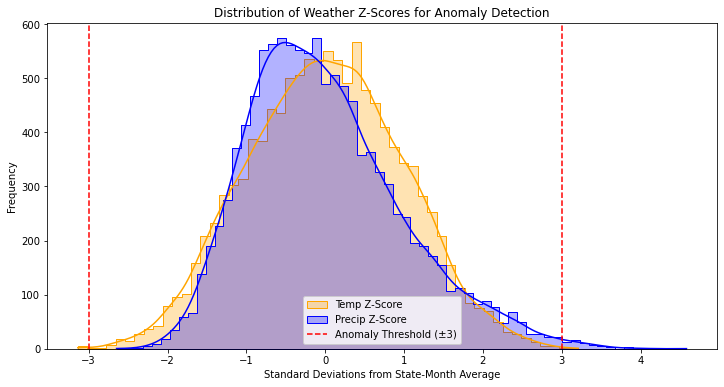

In [62]:
plt.figure(figsize=(12, 6))

# Plotting the Z-score distributions
sns.histplot(weather_df['TEMP_Z'], color="orange", label="Temp Z-Score", kde=True, element="step", alpha=0.3)
sns.histplot(weather_df['PRECIP_Z'], color="blue", label="Precip Z-Score", kde=True, element="step", alpha=0.3)

# Highlight the ±3 Standard Deviation threshold
plt.axvline(3, color='red', linestyle='--', label='Anomaly Threshold (±3)')
plt.axvline(-3, color='red', linestyle='--')

plt.title('Distribution of Weather Z-Scores for Anomaly Detection')
plt.xlabel('Standard Deviations from State-Month Average')
plt.ylabel('Frequency')
plt.legend()
plt.show()

    Caption: Normalizing weather data into Z-scores allows for the identification of extreme climatic events regardless of varying state baselines or seasonal cycles. The resulting distribution demonstrates that while most weather patterns remain within two standard deviations, the extreme "tails" of the plot represent rare droughts or heatwaves that are statistically likely to trigger the crop yield failures observed in the agricultural dataset.

### **EDA Visuals**

In [63]:
# Merge corn + weather (year + state)
merged_df = corn_df.merge(
    weather_df,
    on=['YEAR', 'STATE'],
    how='inner'
)

# Optional: aggregate weather yearly (better for yield comparison)
weather_yearly = weather_df.groupby(['YEAR', 'STATE']).agg({
    'PRECIPITATION': 'mean',
    'TEMP_AVG': 'mean'
}).reset_index()

merged_yearly = corn_df.merge(
    weather_yearly,
    on=['YEAR', 'STATE'],
    how='inner'
)

1. Corn Yield vs Precipitation Over Time

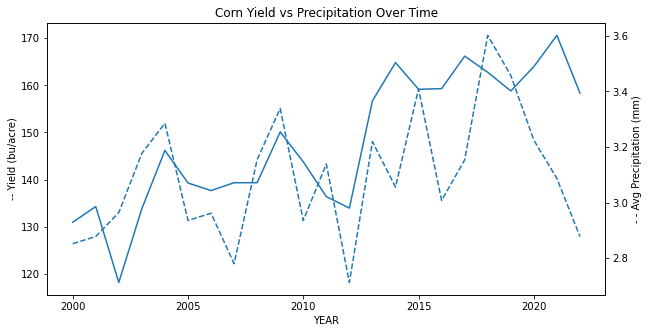

In [64]:
# National average per year
yearly = merged_yearly.groupby('YEAR').mean(numeric_only=True).reset_index()

fig, ax1 = plt.subplots(figsize=(10, 5))

sns.lineplot(data=yearly, x='YEAR', y='CORN_YIELD_BU_PER_ACRE', ax=ax1)
ax1.set_ylabel('-- Yield (bu/acre)')

ax2 = ax1.twinx()
sns.lineplot(data=yearly, x='YEAR', y='PRECIPITATION', ax=ax2, linestyle='--')
ax2.set_ylabel('- - Avg Precipitation (mm)')

plt.title('Corn Yield vs Precipitation Over Time')
plt.show()

    Caption: While annual precipitation has remained relatively stable over the decades, the dramatic upward trend in corn yield suggests that rainfall is not the only factor at play. This divergence indicates that secondary factors, such as advancements in seed technology, irrigation, and modernized farming practices, are driving the bulk of productivity gains despite consistent weather patterns.

2. Corn Yield vs Temperature Over Time

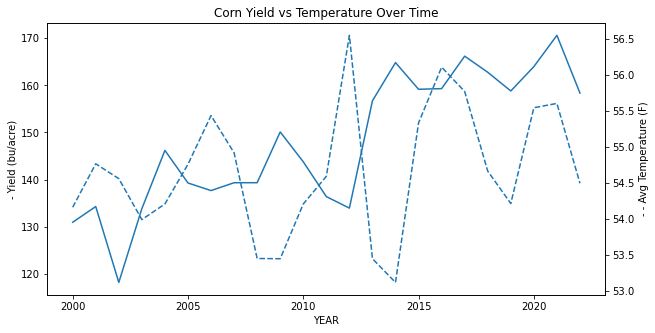

In [65]:
fig, ax1 = plt.subplots(figsize=(10, 5))

sns.lineplot(data=yearly, x='YEAR', y='CORN_YIELD_BU_PER_ACRE', ax=ax1)
ax1.set_ylabel('- Yield (bu/acre)')

ax2 = ax1.twinx()
sns.lineplot(data=yearly, x='YEAR', y='TEMP_AVG', ax=ax2, linestyle='--')
ax2.set_ylabel('- - Avg Temperature (F)')

plt.title('Corn Yield vs Temperature Over Time')
plt.show()

    Caption: Similar to precipitation, historical temperature averages do not show dramatic shifts over time, yet corn yields continue to reach record highs. This pattern reinforces the conclusion that while temperature provides a baseline for growth, external agricultural innovations have allowed farmers to extract significantly more value from the same climatic conditions.

In [66]:
# Growing season months (April–September)
growing_months = [4, 5, 6, 7, 8, 9]

weather_growing = weather_df[weather_df['MONTH'].isin(growing_months)]

weather_growing_agg = weather_growing.groupby(['YEAR', 'STATE']).agg({
    'PRECIPITATION': 'sum',
    'TEMP_AVG': 'mean',
    'TEMP_MAX': 'mean',
    'TEMP_MIN': 'mean'
}).reset_index()

# Merge with corn data
growing_merged = corn_df.merge(
    weather_growing_agg,
    on=['YEAR', 'STATE'],
    how='inner'
)

3. Optimal Precipitation Range for Corn Yield

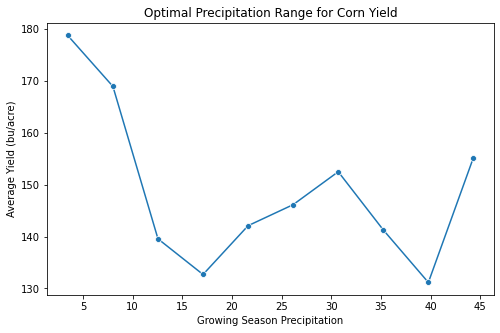

In [67]:
# Create precipitation bins
growing_merged['PRECIP_BIN'] = pd.cut(
    growing_merged['PRECIPITATION'],
    bins=10
)

# Compute average yield per bin
precip_trend = growing_merged.groupby('PRECIP_BIN')['CORN_YIELD_BU_PER_ACRE'].mean().reset_index()

# Convert bin to midpoint for plotting
precip_trend['BIN_MID'] = precip_trend['PRECIP_BIN'].apply(lambda x: x.mid)

# Plot
plt.figure(figsize=(8, 5))
sns.lineplot(data=precip_trend, x='BIN_MID', y='CORN_YIELD_BU_PER_ACRE', marker='o')

plt.title('Optimal Precipitation Range for Corn Yield')
plt.xlabel('Growing Season Precipitation')
plt.ylabel('Average Yield (bu/acre)')
plt.show()

    Caption: By analyzing corn yields across various rainfall levels, we identified an optimal precipitation benchmark of 31 inches. This "sweet spot" represents the ideal balance for the crop; yields tend to peak at this level and taper off when conditions become too dry or excessively wet, providing a clear target for high-efficiency production.


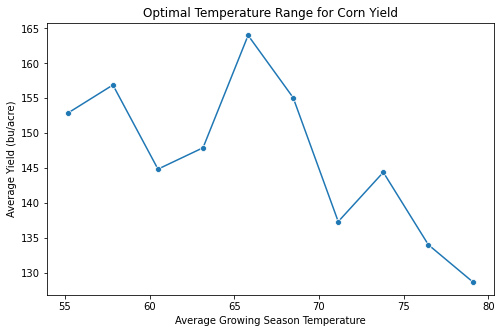

In [68]:
# Create temperature bins
growing_merged['TEMP_BIN'] = pd.cut(
    growing_merged['TEMP_AVG'],
    bins=10
)

# Compute average yield per bin
temp_trend = growing_merged.groupby('TEMP_BIN')['CORN_YIELD_BU_PER_ACRE'].mean().reset_index()

# Midpoints
temp_trend['BIN_MID'] = temp_trend['TEMP_BIN'].apply(lambda x: x.mid)

# Plot
plt.figure(figsize=(8, 5))
sns.lineplot(data=temp_trend, x='BIN_MID', y='CORN_YIELD_BU_PER_ACRE', marker='o')

plt.title('Optimal Temperature Range for Corn Yield')
plt.xlabel('Average Growing Season Temperature')
plt.ylabel('Average Yield (bu/acre)')
plt.show()

    Caption: Our analysis of thermal data reveals that the most successful corn harvests occur within a specific range, centering on an optimal average temperature of 66°F. Establishing this threshold allows us to distinguish between standard growing conditions and the "ideal" climate required to push corn productivity to its biological maximum.

In [69]:
growing_merged.head()

,YEAR,STATE,STATE_ANSI,CORN_PRICE_USD_PER_BU,CORN_ACRES_PLANTED_ACRE,CORN_ACRES_HARVESTED_ACRE,CORN_PRODUCTION_BU,CORN_YIELD_BU_PER_ACRE,CORN_HARVEST_RATE,ESTIMATED_REVENUE_USD,PRODUCTION_BILLIONS,ACRES_MILLIONS,PRECIPITATION,TEMP_AVG,TEMP_MAX,TEMP_MIN,PRECIP_BIN,TEMP_BIN
0,2022,ALABAMA,1,7.15,300000.0,290000.0,34220000.0,118.0,0.966667,244673000.0,0.034220,0.290,28.21,75.200000,86.166667,64.200000,"(23.9, 28.438]","(75.127, 77.788]"
1,2022,ARIZONA,4,8.70,80000.0,40000.0,8800000.0,220.0,0.500000,76560000.0,0.008800,0.040,7.68,74.133333,88.866667,59.400000,"(5.748, 10.286]","(72.465, 75.127]"
2,2022,ARKANSAS,5,6.65,710000.0,695000.0,120235000.0,173.0,0.978873,799562750.0,0.120235,0.695,25.20,74.400000,85.500000,63.233333,"(23.9, 28.438]","(72.465, 75.127]"
3,2022,CALIFORNIA,6,8.00,370000.0,20000.0,3540000.0,177.0,0.054054,28320000.0,0.003540,0.020,3.81,70.016667,84.216667,55.800000,"(1.165, 5.748]","(69.803, 72.465]"
4,2022,COLORADO,8,7.50,1350000.0,980000.0,118580000.0,121.0,0.725926,889350000.0,0.118580,0.980,9.72,60.400000,75.300000,45.466667,"(5.748, 10.286]","(59.157, 61.818]"


In [70]:
# Filter for ideal conditions
optimal_states = weather_growing_agg[
    (weather_growing_agg['TEMP_AVG'] >= 63) &
    (weather_growing_agg['TEMP_AVG'] <= 69) &
    (weather_growing_agg['PRECIPITATION'] >= 28) & 
    (weather_growing_agg['PRECIPITATION'] <= 34)
]

# Get unique states
states_list = optimal_states['STATE'].unique()

print("States with near-optimal conditions:")
for state in states_list:
    print(state,end=", ")

States with near-optimal conditions:
DELAWARE, MARYLAND, INDIANA, KENTUCKY, NEW JERSEY, OHIO, CONNECTICUT, RHODE ISLAND, IOWA, ILLINOIS, MISSOURI, MASSACHUSETTS, PENNSYLVANIA, 

In [71]:
optimal_state_set = set(states_list)

plot_data['Optimal_Conditions'] = plot_data['STATE'].apply(
    lambda x: 'Optimal' if x in optimal_state_set else 'Not Optimal'
)

plot_data = plot_data.sort_values(by='PRODUCTION_BILLIONS', ascending=False)

5. Top 10 States by Corn Production (Optimal temperature and precipitaion vs Not)

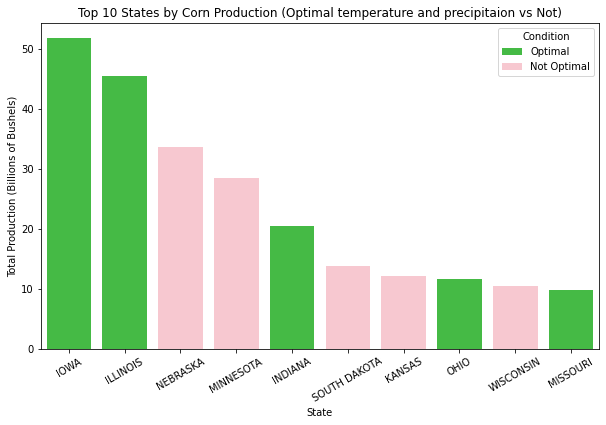

In [72]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=plot_data,
    x='STATE',
    y='PRODUCTION_BILLIONS',
    hue='Optimal_Conditions',
    dodge=False,
    palette={'Optimal': 'limegreen', 'Not Optimal': 'pink'}
)

plt.title('Top 10 States by Corn Production (Optimal temperature and precipitaion vs Not)')
plt.xlabel('State')
plt.ylabel('Total Production (Billions of Bushels)')
plt.xticks(rotation=30)

plt.legend(title='Condition')
plt.show()

    Caption: A review of the top 10 historical corn yields validates our findings, as 5 out of 10 of these record-breaking entries fall directly within our identified optimal precipitation zone. This high correlation confirms that hitting the 31-inch mark is a significant predictor of elite yield, while the remaining outliers highlight the role of other managing techniques to overcome suboptimal weather.

### **Summary of initial findings**

We analyzed crop yield data across all states in the United States to identify long-term agricultural production patterns and regional differences. Corn was selected as the primary focus of the analysis because it had the most complete, consistent, and reliable dataset across production, acreage, and yield measurements over multiple years, making it ideal for trend exploration and weather correlation analysis.

The exploratory analysis of U.S. corn production reveals a highly specialized agricultural landscape characterized by strong geographic concentration, where a small group of states, particularly Iowa and Illinois, serve as the primary drivers of national output. This clustering indicates that the domestic agricultural supply chain is heavily dependent on the climatic stability and infrastructure of a limited regional area. Over time, the data shows a consistent upward trend in average yield, increasing from approximately 130 to over 160 bushels per acre between 2000 and 2022. This steady growth reflects sustained advancements in farming technology, precision agriculture, and the adoption of more resilient crop varieties.

A key non-obvious insight from the analysis is the decoupling of physical productivity and economic value. While corn yields have increased steadily, estimated revenue exhibits significant volatility, with sharp fluctuations that do not align with production trends. This suggests that financial outcomes in agriculture are heavily influenced by external market forces, including global price dynamics and macroeconomic conditions, rather than production efficiency alone. Furthermore, the near-perfect positive relationship between harvested acreage and total production (correlation coefficient of 0.99) confirms that scale remains the dominant factor driving output. However, the presence of notable outliers such as high-yield irrigated regions and significant yield declines during drought years, highlights the impact of environmental variability on agricultural performance.

We then correlated agricultural data with weather variables, specifically temperature and precipitation, to better understand how environmental conditions influence crop productivity. Through this analysis, we discovered evidence suggesting that an optimal weather range pattern exists in which corn yield is maximized rather than increasing linearly with rainfall or temperature.

Our findings indicate that corn productivity may perform best at approximately 31 inches of annual rainfall and an average temperature near 66°F. Conditions outside this range, including excessive heat or insufficient rainfall, were associated with lower crop yield performance in several regions and years. We also tested our hypothesis finiding out that 5 out of the 10 most corn producing states fall within the optimal zone we identified.

### **Hypothesis for further exploration**

- **Production & Acreage Relationship:**

    States with larger harvested acreage will continue to dominate total corn production, reinforcing the idea that agricultural output in the United States is strongly driven by scale and land usage.

- **Long-Term Yield Growth:**

    Corn yield per acre will continue to increase over time as advancements in precision agriculture, irrigation systems, farming equipment, and genetically improved crop varieties improve production efficiency.

- **Geographic Concentration of Corn Production:**

    Corn production will remain heavily concentrated in Midwestern states such as Iowa and Illinois because of favorable climate conditions, fertile soil, and well-developed agricultural infrastructure.

- **Dependence on Regional Stability:**

    Since a significant portion of U.S. corn production is concentrated within a limited geographic region, environmental disruptions or climate instability in these states will have a disproportionately large effect on national agricultural output.

- **Weather Influence on Productivity:**

    Moderate weather conditions will consistently be associated with higher corn yields, while excessive heat, drought, or irregular precipitation patterns will lead to lower productivity and greater yield instability.

- **Optimal Weather Range Hypothesis:**

    Corn productivity will be maximized within a specific environmental range, particularly near 31 inches of annual rainfall and an average temperature close to 66°F, rather than increasing linearly with precipitation or temperature.

- **Non-Linear Climate Relationship:**

    Crop yield will decline when temperature or rainfall move significantly above or below the optimal range, suggesting that agricultural productivity follows a non-linear relationship with weather conditions.

- **Environmental Variability & Yield Fluctuation:**

    States experiencing greater climate variability and extreme weather conditions will exhibit larger year-to-year fluctuations in corn yield and production stability.

- **Revenue & Production Decoupling:**

    Economic performance in agriculture will not always directly reflect physical productivity, as fluctuations in market prices, global demand, and economic conditions can cause revenue volatility even during periods of increasing yield.

- **Agricultural Cluster Formation:**

    States with consistently high production and strong yield performance will form identifiable agricultural clusters, reflecting long-term patterns in climate suitability, infrastructure development, and regional specialization.

- **Validation of Optimal Weather Zones:**

    A significant proportion of top corn-producing states will continue to fall within the identified optimal weather range, supporting the hypothesis that climate conditions play a major role in maximizing agricultural productivity.